In [1]:
import os

###############################################################################
# Decide on CPU or GPU here
use_gpu = True  # Set to False if you want CPU only
###############################################################################

if use_gpu:
    # Prevent JAX from preallocating most of the GPU memory
    os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
    # Force JAX to use GPU
    import jax
    jax.config.update("jax_platform_name", "gpu")
else:
    # Force JAX to use CPU
    import jax
    jax.config.update("jax_platform_name", "cpu")

In [2]:
import numpy as np
from jax import jit, vjp, vmap, value_and_grad, random, nn
import jax
from jax import numpy as jnp
from jax import lax
from jaxdf.operators import compose
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from IPython.display import display, clear_output

# from cmcrameri import cm

import optax
import equinox as eqx
from jax.example_libraries import optimizers
from typing import Tuple, Callable, Optional, Union


from jwave.geometry import Domain, Medium
from jwave.signal_processing import smooth

key = random.PRNGKey(42)  # Random seed
Array = jnp.ndarray



from hybridoed.forward import create_src_field, generate_2D_gridded_src_rec_positions, ricker_wavelet, acoustic2D, acoustic2D_pml,acoustic2D_pml_minmem, acoustic2D_pml_4th_minmem, generate_src_rec_positions, acoustic2D_cpml_minmem, cfl_dt, solve_phi_wave_2d

from hybridoed.oed import *


2026-02-26 10:59:47.877107: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.5.82. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [3]:


# ---- physical domain (meters) ----
Lx, Ly = 0.6, 0.6               # FIXED domain size
c_min = 1200.0            
c_max = 5750.0            

# ---- resolution chosen ONCE for the highest test frequency ----
f0_max = 25e3                     # highest center freq you'll run
fmax   = 2.0 * f0_max             # Ricker top-end
PPW    = 8                       # for 2nd-order space; 10–12 is typical

dx_req = c_min / (PPW * fmax)
dx = dy = dx_req                  # keep this fixed for all runs

# grid size from physical size
nx = int(np.floor(Lx / dx)) + 1
ny = int(np.floor(Ly / dy)) + 1
dx = Lx / (nx - 1)                # snap dx to fit exactly
dy = Ly / (ny - 1)

print(f"nx, ny = {nx}, {ny}  |  dx = {dx*1e3:.2f} mm, dy = {dy*1e3:.2f} mm")

# ---- stable time step (keep FIXED) ----
dt_max = min(dx,dy) / (c_max * np.sqrt(2.0))   # 2-D CFL for staggered first-order
dt = 0.8 * dt_max                              # margin
print(f"dt = {dt*1e6:.2f} µs")

# ---- PML thickness in METERS (fixed), converted to cells ----
pml_thickness_m = 0.1                         # e.g., 3 cm per side
pml_width = max(4, int(round(pml_thickness_m / dx)))
print(f"pml_width = {pml_width} cells (~{pml_width*dx*100:.1f} cm)")

# ---- material model (fixed in meters) ----
velocity = c_min
density  = 1180.0

true_model = jnp.full((nx, ny), velocity, dtype=jnp.float32)
homo_model = jnp.full((nx, ny), velocity, dtype=jnp.float32)
# scatterer defined in METERS, then mapped to indices
scx0, scx1 = 0.05+0.15 +0.05-0.035/2,  0.05+0.15 +0.05+0.035/2 
scy0, scy1 =  0.15+0.15+0.05-0.035/2,  0.15+0.15+0.05+0.035/2  
# diag_add = 0.15
# scx0, scx1 = diag_add + 0.15 +0.05-0.035/2, diag_add + 0.15 +0.05+0.035/2 
# scy0, scy1 = diag_add + 0.15+0.05-0.035/2, diag_add + 0.15+0.05+0.035/2
ix0, ix1 = int(scx0/dx), int(scx1/dx)
iy0, iy1 = int(scy0/dy), int(scy1/dy)
true_model = true_model.at[ix0:ix1, iy0:iy1].set(c_max)

# make a blurred version of the true model for the homogeneous case
from scipy.ndimage import gaussian_filter as gaussian
# true_model_np = np.array(true_model)
# homo_model_np = gaussian(true_model_np, sigma=5)
# homo_model = jnp.array(homo_model_np, dtype=jnp.float32)

density_grid = jnp.full_like(true_model, density)
density_grid = density_grid.at[ix0:ix1, iy0:iy1].set(4500.0)  # set density in scatterer

# ---- geometry in METERS (then to index floats) ----
# One source 2 cm from left wall, centered vertically
# src_x_m, src_y_m = 0.3,0.3
# define a 2D grid of sources        
src_x_m_list = np.linspace(0.15, 0.45, 3)  # reverse to have source on the left for plotting
src_y_m_list = np.linspace(0.15, 0.45, 3)
src_indices = []
for x in src_x_m_list:
    for y in src_y_m_list:
        src_indices.append([x / dx, y / dy])

src_indices = jnp.array(src_indices, dtype=jnp.float32)

# 2D grid of receivers: 
n_rx, n_ry = 30,30
rec_x_m = np.linspace(0.15, 0.45, n_rx)  # reverse to match source side for plotting
rec_y_m = np.linspace(0.15, 0.45, n_ry)
rec_xx, rec_yy = np.meshgrid(rec_x_m, rec_y_m, indexing='ij')
receiver_is = jnp.stack([rec_xx.ravel() / dx, rec_yy.ravel() / dy], axis=1).astype(jnp.float32)

# ---- time window FIXED in seconds ----
T = 500e-6                     # e.g., 120 µs fixed
n_steps = int(np.ceil(T / dt))
print(f"n_steps = {n_steps}, total time = {n_steps*dt*1e6:.1f} µs")

# ---- run for any f0 (ONLY f0 changes) ----
f0 = 25e3  # try 10e3, 25e3, 40e3 without changing grid/dt
seis_total = []
seis_homo_total = []
for source_idx in range(src_indices.shape[0]):
    ys = acoustic2D_cpml_minmem(
        true_model, density_grid, src_indices[source_idx], f0,
        dx, dy, dt, n_steps,
        receiver_is=receiver_is,
        output_wavefield=True,
        pml_width=pml_width,
        R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
    )
    seis = ys[0]  # (n_steps, Nrec)
    wavefields_test = ys[1]  # (n_steps, nx, ny)
    seis_total.append(seis)

    ys_homo = acoustic2D_cpml_minmem(
        homo_model, density_grid, src_indices[source_idx], f0,
        dx, dy, dt, n_steps,
        receiver_is=receiver_is,
        output_wavefield=True,
        pml_width=pml_width,
        R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
    )
    seis_homo = ys_homo[0]  # (n_steps, Nrec)
    seis_homo_total.append(seis_homo)



# print("------Now running with solve_phi_wave_2d------")
# # dt = cfl_dt(true_model, (dx, dy), cfl=0.40)
# print(f"Chosen time step: {dt:.2e} seconds")
# n_steps = int(np.ceil(T / dt))
# print(f"Number of time steps: {n_steps} for total time {n_steps*dt:.2e} seconds")

# # arbitrary wavelet array (you can pass literally anything)
time = jnp.arange(n_steps) * dt
# my_wavelet_array = ricker_wavelet(time, f0, 5.8*10e-6)  # (nt,)
# plt.plot(time*1e6, my_wavelet_array)
# wavelet = jnp.asarray(my_wavelet_array*10e9, dtype=jnp.float32)  # (nt,)



# out = solve_phi_wave_2d(
#     c=true_model,                 # (nx, ny) velocity model [m/s]
#     rho=density_grid,                 # or None
#     spacing=(dx, dy),
#     dt=dt,
#     source_xy=src_indices[0],  
#     source_wavelet=wavelet,
#     receiver_xy=receiver_is,  
# )

seis_total = jnp.array(seis_total)
seis_homo_total = jnp.array(seis_homo_total)
seis_total = jnp.swapaxes(seis_total, -1, -2)
seis_homo_total = jnp.swapaxes(seis_homo_total, -1, -2)


nx, ny = 201, 201  |  dx = 3.00 mm, dy = 3.00 mm
dt = 0.30 µs
pml_width = 33 cells (~9.9 cm)
n_steps = 1695, total time = 500.3 µs


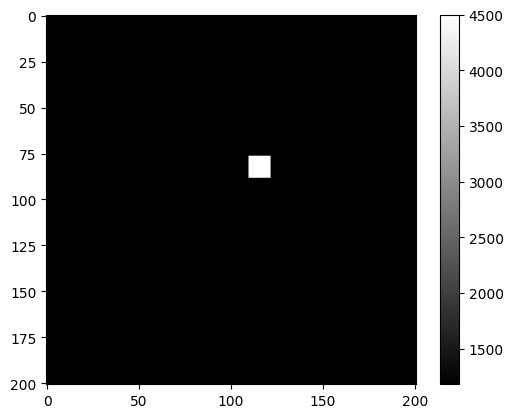

In [4]:
plt.imshow(density_grid, cmap='grey')
plt.colorbar()

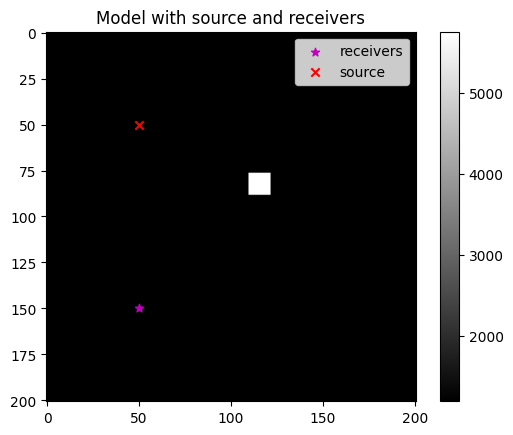

In [5]:
src_idx_to_plot = 0
rec_idx_to_plot = -30
plt.scatter(receiver_is[rec_idx_to_plot,1], receiver_is[rec_idx_to_plot,0], c="m", marker="*", label="receivers", alpha=0.99)
plt.scatter(src_indices[src_idx_to_plot][1], src_indices[src_idx_to_plot][0], c="r", marker="x", label="source")


# plt.scatter(receiver_is[:,1], receiver_is[:,0], c="m", marker="*", label="receivers", alpha=0.1)

# plt.scatter(src_indices[:,1], src_indices[:,0], c="r", marker="x", label="source")
plt.imshow(true_model, cmap='grey')
plt.colorbar()
plt.legend()
plt.title("Model with source and receivers")
plt.show()

In [6]:
# make a shot gather with the x axis being the y position
# sorte the trace by y position
source_x, source_y = src_indices[0][0], src_indices[0][1]
receiver_x, receiver_y = receiver_is[:,0], receiver_is[:,1]
sorted_indices_y = np.argsort(receiver_y)
sorted_offsets_y = receiver_y[sorted_indices_y]
sorted_traces_y = seis[:, sorted_indices_y]
n_traces_y = sorted_traces_y.shape[1]
n_samples_y = sorted_traces_y.shape[0]

# sorted_traces_y_solve = out["phi_rec"][:, sorted_indices_y]

# extract a receiver line at a fixed x position (e.g., the middle of the domain)
fixed_x = Lx / 2
# find the receiver closest to this x position
closest_idx = np.argmin(np.abs(receiver_x - fixed_x))
fixed_x_trace = seis[:, closest_idx]


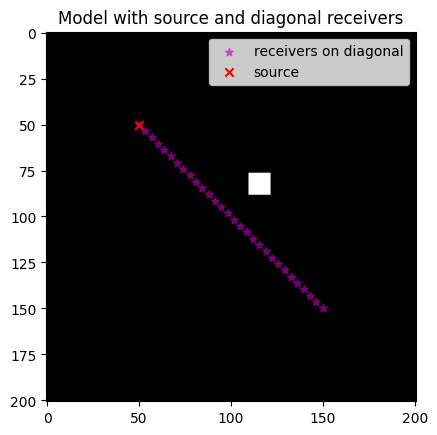

In [7]:
# plot only the receivers on the diagonal
receiver_is_diag = receiver_is[receiver_is[:,0] == receiver_is[:,1]]
plt.scatter(receiver_is_diag[:,1], receiver_is_diag[:,0], c="m", marker="*", label="receivers on diagonal", alpha=0.5)
plt.scatter(source_x, source_y, c="r", marker="x", label="source")
plt.imshow(true_model,cmap='grey')
plt.legend()
plt.title("Model with source and diagonal receivers")
plt.show()

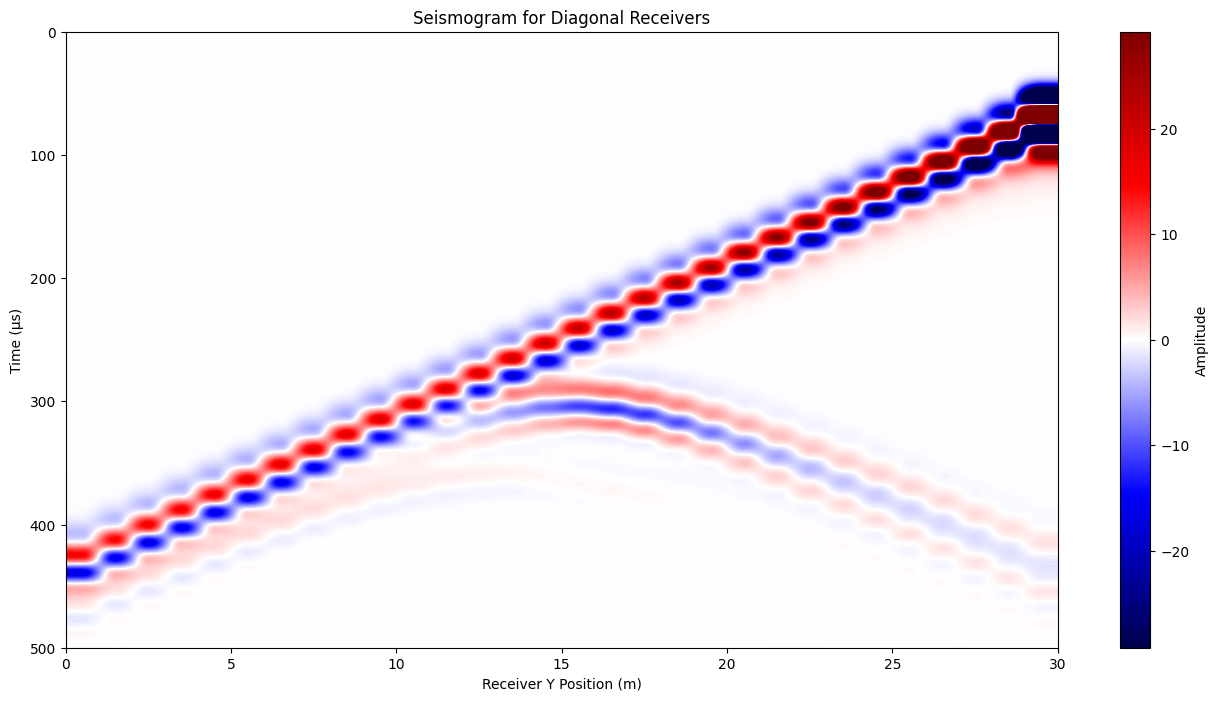

In [8]:
# plot only the traces from the diagonal receivers as an image
plt.figure(figsize=(16,8))
receiver_is_diag = receiver_is[receiver_is[:,0] == receiver_is[:,1]]
diag_indices = np.where((receiver_is[:,0] == receiver_is[:,1]))[0]
# diag_traces = out["phi_rec"][:, diag_indices]
diag_traces = seis[:, diag_indices]
# plt.imshow(diag_traces, aspect='auto', extent=[ receiver_is[diag_indices,1].min() * dx, receiver_is[diag_indices,1].max() * dx,time[-1]*1e6,0],cmap='seismic', vmin=-np.max(np.abs(diag_traces))/10, vmax=np.max(np.abs(diag_traces))/10)
plt.imshow(diag_traces, aspect='auto', extent=[0,30, T*1e6,0],cmap='seismic', vmin=-np.max(np.abs(diag_traces))/10, vmax=np.max(np.abs(diag_traces))/10)
plt.colorbar(label='Amplitude')
plt.ylabel('Time (µs)')
plt.xlabel('Receiver Y Position (m)')
plt.title('Seismogram for Diagonal Receivers')
plt.show()

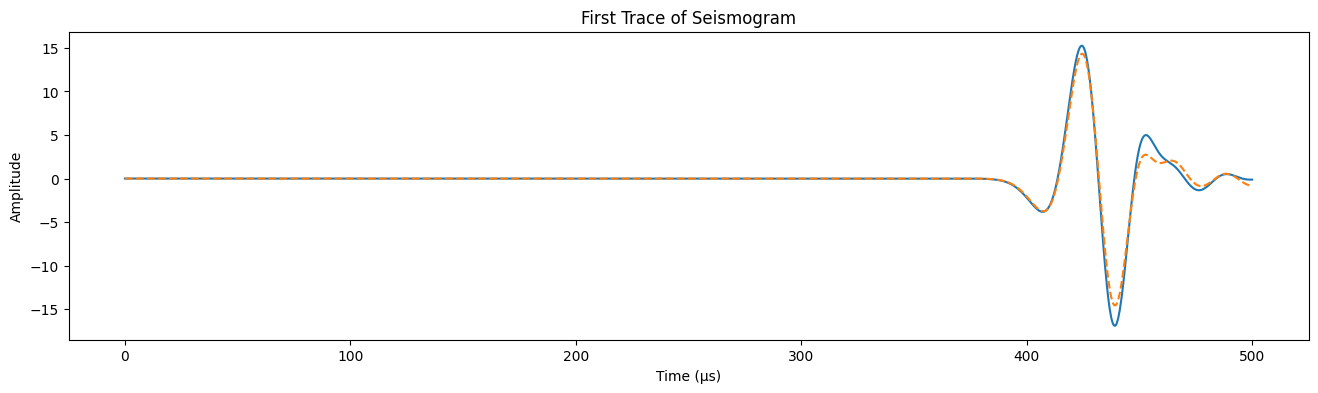

In [9]:
# plot only the firts trace
# plt.plot(time*1e6, out["phi_rec"][:, 0])
plt.figure(figsize=(16,4))
plt.plot(time*1e6, seis[:, 0], label="Original")
plt.plot(time*1e6, seis_homo[:, 0], label="Homogeneous", linestyle='--')
# plt.plot(time*1e6, out["phi_rec"][:, 0])
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude')
plt.title('First Trace of Seismogram')
plt.show()

In [10]:
def apply_dispersion_phase_shift(
    traces: np.ndarray,
    dt: float,
    dist: np.ndarray,
    cp_of_f,
    c_ref: float,
    fmin: float | None = None,
    fmax: float | None = None,
    phase_only: bool = True,
    eps: float = 1e-12,
) -> np.ndarray:
    """
    Apply an 'engineering' dispersive correction by phase-shifting in frequency domain.

    Parameters
    ----------
    traces : (n_traces, n_samples) array
        Time series at each receiver.
    dt : float
        Sampling interval [s].
    dist : (n_traces,) array
        Source-to-receiver distance for each trace [m].
    cp_of_f : callable or (f, cp) tuple
        If callable: cp_of_f(f_hz) -> phase velocity [m/s] for array f_hz.
        If tuple: (f_hz_array, cp_array) used with linear interpolation.
    c_ref : float
        Reference (nondispersive) velocity used in your acoustic simulation [m/s].
    fmin, fmax : float or None
        Optional band-limits [Hz] where dispersion is applied.
        Outside the band, no phase correction is applied.
    phase_only : bool
        If True, keep amplitude unchanged (recommended). If False, you can extend this
        later to include attenuation (not implemented here).
    eps : float
        Small number to avoid division by zero.

    Returns
    -------
    disp_traces : (n_traces, n_samples) jnp array
        Dispersed traces.
    """
    import jax.numpy as jnp
    
    traces = jnp.asarray(traces, dtype=float)
    dist = jnp.asarray(dist, dtype=float)

    if traces.ndim != 2:
        raise ValueError("traces must be 2D (n_traces, n_samples)")
    n_tr, nt = traces.shape
    if dist.shape != (n_tr,):
        raise ValueError(f"dist must have shape (n_traces,), got {dist.shape}")

    # Build cp(f) accessor
    if isinstance(cp_of_f, tuple) or isinstance(cp_of_f, list):
        f_tab = jnp.asarray(cp_of_f[0], dtype=float)
        cp_tab = jnp.asarray(cp_of_f[1], dtype=float)
        if f_tab.ndim != 1 or cp_tab.ndim != 1 or f_tab.size != cp_tab.size:
            raise ValueError("cp_of_f as tuple must be (f_array, cp_array) with same length")

        def _cp(f_hz: np.ndarray) -> np.ndarray:
            f_clipped = jnp.clip(f_hz, f_tab.min(), f_tab.max())
            return jnp.interp(f_clipped, f_tab, cp_tab)
    elif callable(cp_of_f):
        _cp = cp_of_f
    else:
        raise ValueError("cp_of_f must be a callable or a (f_array, cp_array) tuple")

    # Frequency axis for rFFT
    f = np.fft.rfftfreq(nt, d=dt)
    omega = 2.0 * np.pi * f

    # Compute cp(f)
    cp = np.asarray(_cp(f), dtype=float)
    cp = np.maximum(cp, eps)

    # Compute delta slowness and delta tau per trace
    delta_s = (1.0 / cp) - (1.0 / max(c_ref, eps))
    delta_tau = dist[:, None] * delta_s[None, :]

    # Optional band-limit where to apply correction
    if fmin is not None or fmax is not None:
        mask = np.ones_like(f, dtype=bool)
        if fmin is not None:
            mask &= (f >= fmin)
        if fmax is not None:
            mask &= (f <= fmax)
        delta_tau = np.where(mask[None, :], delta_tau, 0.0)

    # FFT traces
    U = np.fft.rfft(traces, axis=1)

    # Apply phase shift
    phase = np.exp(-1j * omega[None, :] * delta_tau)
    U_disp = U * phase

    # Back to time
    disp_traces = np.fft.irfft(U_disp, n=nt, axis=1)

    return jnp.asarray(disp_traces)


In [11]:
def apply_dispersion_phase_shift_jax(
    traces: Array,
    dt: float,
    dist: Array,
    c_ref: float,
    *,
    # Choose ONE of the two ways to provide cp(f):
    cp_fun: Optional[Callable[[Array], Array]] = None,
    cp_table: Optional[Tuple[Array, Array]] = None,  # (f_tab_hz, cp_tab)
    # Band limits:
    fmin: Optional[float] = None,
    fmax: Optional[float] = None,
    # Numerics:
    eps: float = 1e-12,
) -> Array:
    """
    JAX-differentiable dispersive correction by phase shifting in the frequency domain.

    Parameters
    ----------
    traces : (n_traces, n_samples) array
        Time series at each receiver.
    dt : float
        Sampling interval [s].
    dist : (n_traces,) array
        Source-to-receiver distance for each trace [m].
    c_ref : float
        Reference (nondispersive) velocity used in the acoustic simulation [m/s].
    cp_fun : callable, optional
        JAX-compatible function: cp_fun(f_hz) -> phase velocity [m/s] for f_hz array.
        NOTE: if you plan to `jit` this function, pass cp_fun as a *static* argument
        (see example below).
    cp_table : (f_tab_hz, cp_tab), optional
        Tabulated phase velocity. Uses linear interpolation (jnp.interp).
    fmin, fmax : optional float
        Frequency band [Hz] where dispersion is applied. Outside, no correction.
    eps : float
        Small number to avoid division by zero.

    Returns
    -------
    disp_traces : (n_traces, n_samples) array
        Dispersed traces (real-valued).
    """
    traces = jnp.asarray(traces)
    dist = jnp.asarray(dist)

    if traces.ndim != 2:
        raise ValueError("traces must be 2D (n_traces, n_samples)")
    n_tr, nt = traces.shape
    if dist.shape != (n_tr,):
        raise ValueError(f"dist must have shape (n_traces,), got {dist.shape}")

    # --- frequency axis (rFFT) ---
    f = jnp.fft.rfftfreq(nt, d=dt)  # (n_freq,)
    omega = 2.0 * jnp.pi * f

    # --- cp(f) ---
    if (cp_fun is None) == (cp_table is None):
        raise ValueError("Provide exactly one of cp_fun or cp_table.")

    if cp_table is not None:
        f_tab, cp_tab = cp_table
        f_tab = jnp.asarray(f_tab)
        cp_tab = jnp.asarray(cp_tab)
        if f_tab.ndim != 1 or cp_tab.ndim != 1 or f_tab.size != cp_tab.size:
            raise ValueError("cp_table must be (f_tab_1d, cp_tab_1d) with same length")

        f_clipped = jnp.clip(f, jnp.min(f_tab), jnp.max(f_tab))
        cp = jnp.interp(f_clipped, f_tab, cp_tab)
    else:
        cp = jnp.asarray(cp_fun(f))

    cp = jnp.maximum(cp, eps)
    c_ref_safe = jnp.maximum(jnp.asarray(c_ref, dtype=cp.dtype), eps)

    # delta_s(f) = 1/cp(f) - 1/c_ref
    delta_s = (1.0 / cp) - (1.0 / c_ref_safe)  # (n_freq,)

    # delta_tau(trace, f) = dist(trace) * delta_s(f)
    delta_tau = dist[:, None] * delta_s[None, :]  # (n_tr, n_freq)

    # --- optional band-limiting of the correction ---
    if (fmin is not None) or (fmax is not None):
        mask = jnp.ones_like(f, dtype=bool)
        if fmin is not None:
            mask = mask & (f >= fmin)
        if fmax is not None:
            mask = mask & (f <= fmax)
        delta_tau = jnp.where(mask[None, :], delta_tau, 0.0)

    # --- FFT, phase shift, iFFT ---
    U = jnp.fft.rfft(traces, axis=1)  # (n_tr, n_freq) complex
    phase = jnp.exp((-1j) * omega[None, :] * delta_tau)  # (n_tr, n_freq) complex
    U_disp = U * phase
    disp_traces = jnp.fft.irfft(U_disp, n=nt, axis=1)  # (n_tr, nt) real

    return disp_traces


In [12]:
diag_traces.T.shape

(30, 1695)

In [13]:
import pandas as pd
# path to your exported file
file = "dispersion_curve_test_A_Lamb.txt"

# read file (it is comma-separated)
df = pd.read_csv(file)

f_A0 = df["A0 f (kHz)"].values
c_A0 = df["A0 Phase velocity (m/ms)"].values

# Remove NaNs (important: higher modes end earlier)
mask = ~np.isnan(f_A0) & ~np.isnan(c_A0)

f_A0 = f_A0[mask] * 1e3        # kHz → Hz
c_A0 = c_A0[mask] * 1e3        # m/ms → m/s

In [14]:
# traces: (nrec, nt)
# dt in seconds
# dist: (nrec,) in meters
# dist only for the diagonal receivers
# dist = np.sqrt((receiver_is[diag_indices,0] - source_x)**2 + (receiver_is[diag_indices,1] - source_y)**2) * dx
# Provide cp(f) as arrays (f_hz, cp_mps)
# f_cp = np.array([...])
# cp = np.array([...])

# disp = apply_dispersion_phase_shift(diag_traces.T, dt, dist, (f_A0, c_A0), c_ref=1200.0)

In [15]:
# lest now apply the dispersion correction to the compelte set of traces, not just the diagonal ones
# dist for all receivers
seis_traces_disp = []
for src in range(src_indices.shape[0]):
    dist_all = jnp.sqrt(
        (receiver_is[:,0] - src_indices[src,0])**2 +
        (receiver_is[:,1] - src_indices[src,1])**2) * dx
    print(dist_all.shape)

    out = apply_dispersion_phase_shift_jax(seis_total[src], dt, dist_all, c_ref=c_min*0.75, cp_table=(f_A0, c_A0))
    seis_traces_disp.append(out)


(900,)
(900,)
(900,)
(900,)
(900,)
(900,)
(900,)
(900,)
(900,)


In [16]:
seis_traces_disp = jnp.array(seis_traces_disp)
seis_traces_disp.shape, seis_total.shape

((9, 900, 1695), (9, 900, 1695))

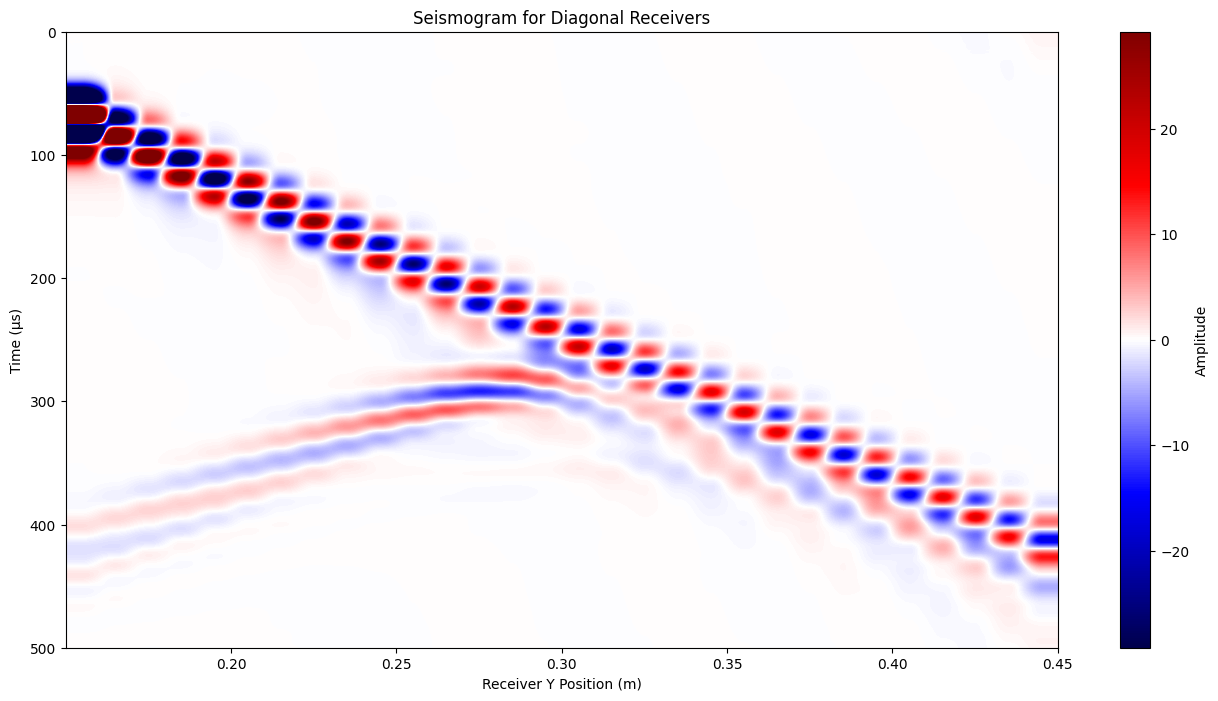

In [17]:
# plot only the traces from the diagonal receivers as an image
src_idx_to_plot = 0
rec_lines = receiver_is[:,0] == receiver_is[:,1]
plt.figure(figsize=(16,8))
plt.imshow(seis_traces_disp[src_idx_to_plot,rec_lines].T, aspect='auto', extent=[ receiver_is[diag_indices,1].min() * dx, receiver_is[diag_indices,1].max() * dx,T*1e6,0],cmap='seismic', vmin=-np.max(np.abs(seis_traces_disp[src_idx_to_plot]))/10, vmax=np.max(np.abs(seis_traces_disp[src_idx_to_plot]))/10)
plt.colorbar(label='Amplitude')
plt.ylabel('Time (µs)')
plt.xlabel('Receiver Y Position (m)')
plt.title('Seismogram for Diagonal Receivers')
plt.show()

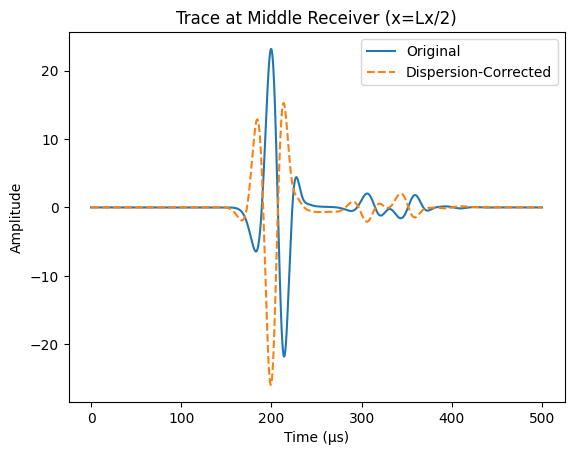

In [18]:
# plot the middle trace (closest to x=Lx/2)
# plt.plot(time*1e6, out["phi_rec"][:, 10], label="Original")
plt.plot(time*1e6, seis_total[0,15, :], label="Original")
plt.plot(time*1e6, seis_traces_disp[0,15,:], label="Dispersion-Corrected", linestyle='--')
plt.xlabel('Time (µs)')
plt.ylabel('Amplitude')
plt.title('Trace at Middle Receiver (x=Lx/2)')
plt.legend()
plt.show()

In [19]:
salvus_out = np.load("diagonal_traces_all.npz")  # assuming the traces are saved in a numpy file
salvus_traces = salvus_out["diagonal_traces_all"] [0]
salvus_traces.shape

(30, 4031)

In [20]:
seis_total.shape

(9, 900, 1695)

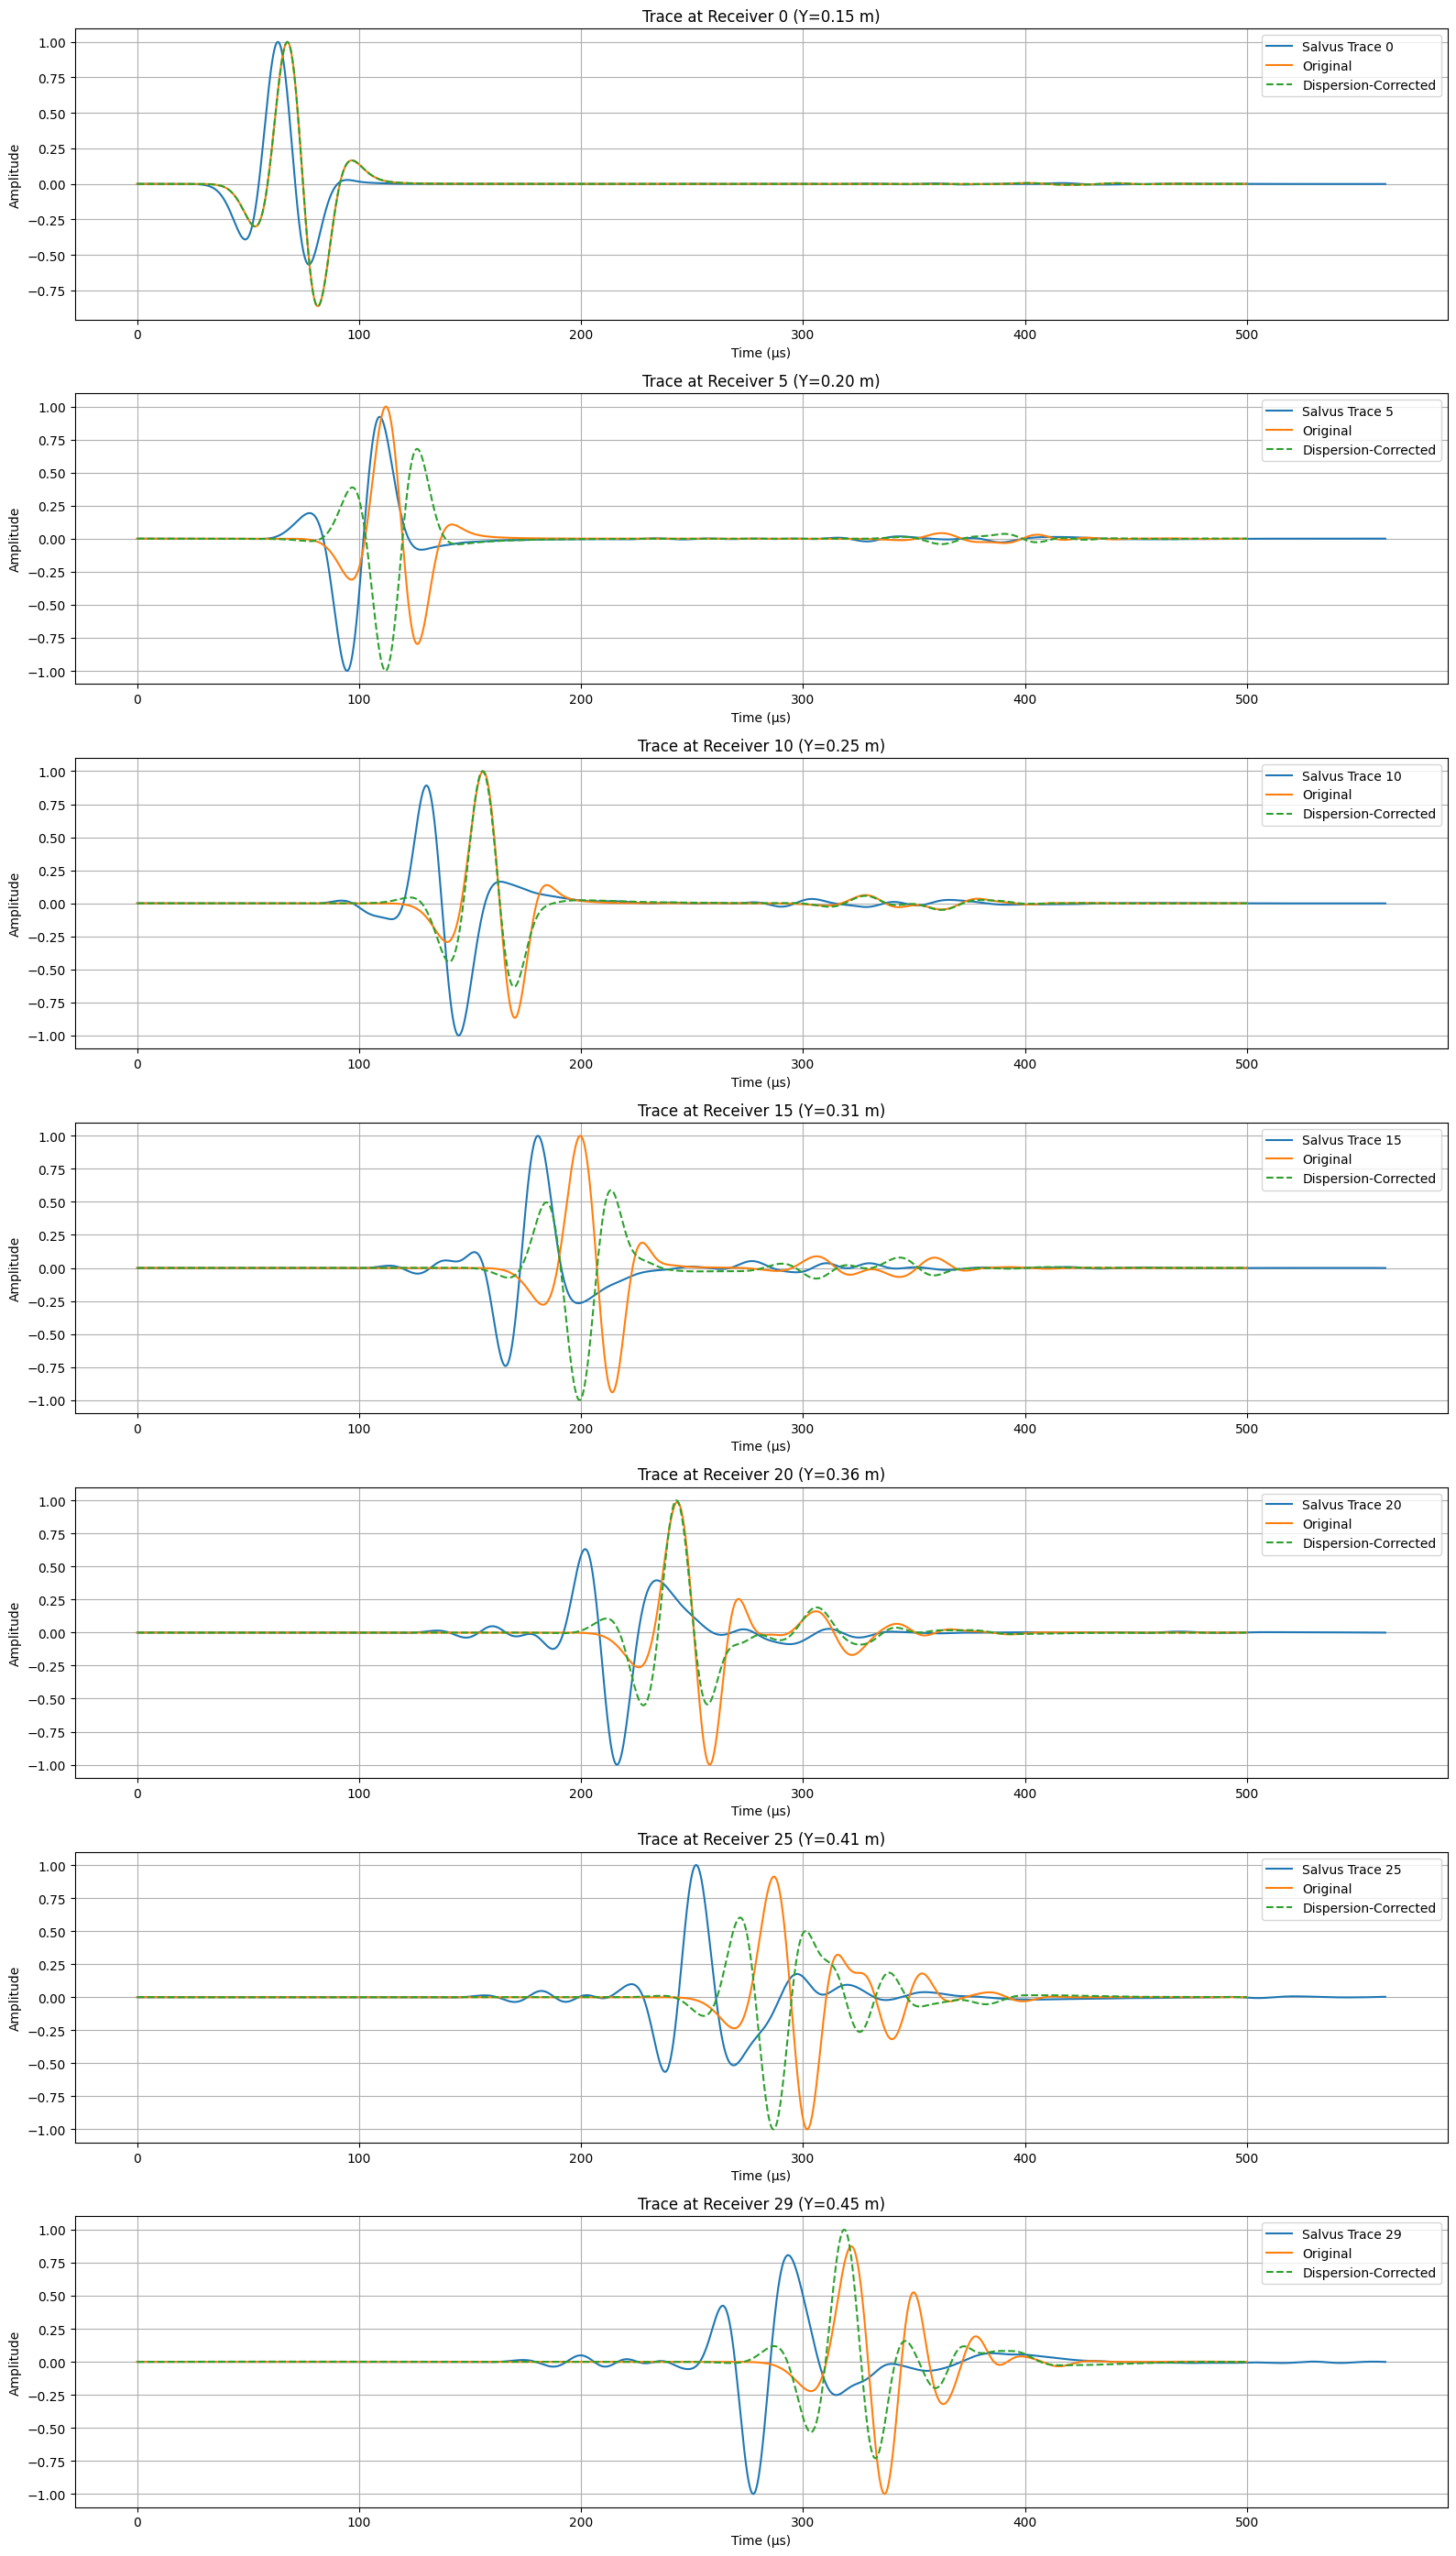

In [21]:
# read the traces from salvus
# salvus_out = np.load("diagonal_traces_all.npz")  # assuming the traces are saved in a numpy file
salvus_out = np.load("all_traces.npz")
# salvus_traces = salvus_out["diagonal_traces_all"][-1] 
salvus_traces = salvus_out["all_traces"]
salvus_time = salvus_out["t"]
trace_idx = [0,5,10,15,20,25,29]  # indices of traces to plot
src_idx_to_plot = 0

# Create a single big figure with all traces
fig, axes = plt.subplots(len(trace_idx), 1, figsize=(16, 4*len(trace_idx)))

for i, idx in enumerate(trace_idx):
    ax = axes[i] if len(trace_idx) > 1 else axes
    ax.plot(salvus_time*1e6, salvus_traces[src_idx_to_plot, idx, :]/np.max(np.abs(salvus_traces[src_idx_to_plot, idx, :])), label=f"Salvus Trace {idx}")
    ax.plot(time*1e6, seis_total[src_idx_to_plot, idx,:]/np.max(np.abs(seis_total[src_idx_to_plot, idx,:])), label="Original")
    # ax.plot(time*1e6, seis_homo_total[src_idx_to_plot, idx,:]/np.max(np.abs(seis_homo_total[src_idx_to_plot, idx,:])), label="Homogeneous", linestyle='--')
    ax.plot(time*1e6, seis_traces_disp[src_idx_to_plot, idx,:]/np.max(np.abs(seis_traces_disp[src_idx_to_plot, idx,:])), label="Dispersion-Corrected", linestyle='--')
    ax.grid()
    ax.set_xlabel('Time (µs)')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Trace at Receiver {idx} (Y={receiver_is[diag_indices[idx],1]*dx:.2f} m)')
    ax.legend()

plt.tight_layout()
# plt.savefig('diagonal_traces_comparison_dispersive.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Inversion setup

In [22]:
salvus_out = np.load("all_traces.npz")
salvus_traces = salvus_out["all_traces"]
salvus_time = salvus_out["t"]
print(salvus_traces.shape, salvus_time.shape, time.shape)
# interpolate salvus_traces to match the time axis of our simulation if needed
# For example, if salvus_traces has a different time sampling, you can use np.interp to interpolate it to the same time points as 'time' used in our simulation.
if len(salvus_time) != len(time):
    salvus_traces_interp = np.zeros((salvus_traces.shape[0], salvus_traces.shape[1], len(time)))
    for i in range(salvus_traces.shape[0]):
        for j in range(salvus_traces.shape[1]):
            salvus_traces_interp[i, j, :] = np.interp(time, salvus_time, salvus_traces[i, j, :])
    salvus_traces = salvus_traces_interp


salvus_traces.shape, time.shape, seis_total.shape

(9, 900, 4031) (4031,) (1695,)


((9, 900, 1695), (1695,), (9, 900, 1695))

In [23]:
# lest normalize each individuals tracs of the salvus data with respect to the maximum absolute value of that trace
salvus_traces_normalized = salvus_traces / jnp.max(jnp.abs(salvus_traces), axis=2, keepdims=True)

In [24]:
# lets remove the center source from the salvus which is 4th source in the list
salvus_traces_normalized = jnp.delete(salvus_traces_normalized, 4, axis=0)
salvus_traces_normalized.shape, seis_total.shape

((8, 900, 1695), (9, 900, 1695))

Array([[1200., 1200., 1200., ..., 1200., 1200., 1200.],
       [1200., 1200., 1200., ..., 1200., 1200., 1200.],
       [1200., 1200., 1200., ..., 1200., 1200., 1200.],
       ...,
       [1200., 1200., 1200., ..., 1200., 1200., 1200.],
       [1200., 1200., 1200., ..., 1200., 1200., 1200.],
       [1200., 1200., 1200., ..., 1200., 1200., 1200.]], dtype=float32)

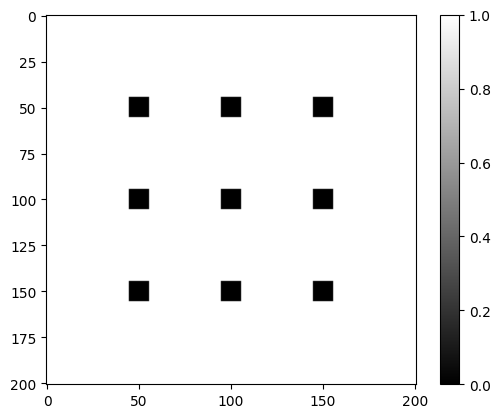

In [25]:
mask = jnp.ones(true_model.shape, dtype=jnp.float32)
# mask the position of the source (and a bit around) to avoid the optimizer trying to fit those areas
for src in range(src_indices.shape[0]):
    radius = 5  # in grid points
    src_x_idx = int(src_indices[src,0])
    src_y_idx = int(src_indices[src,1])
    x_min = max(src_x_idx - radius, 0)
    x_max = min(src_x_idx + radius + 1, mask.shape[0])
    y_min = max(src_y_idx - radius, 0)
    y_max = min(src_y_idx + radius + 1, mask.shape[1])
    mask = mask.at[x_min:x_max, y_min:y_max].set(0.0)


plt.imshow(mask, cmap='gray')
plt.colorbar()

def get_sound_speed(params):
    return params + compose(params)(nn.sigmoid)

# initial model is the blurred model
params = jnp.array(homo_model)
# params = true_model
# params = homogenous_model
# params = medium.sound_speed * 0.1 + 
params

In [26]:
def smooth_fun(gradient):
    # x = gradient.on_grid[..., 0]
    x = gradient * mask
    for _ in range(3):
        x = smooth(x)
    return x 
@jit
def fwi(src_position):
    # print("source position in fwi", src_position)
    num_steps_fwi = 500
    # num_steps_fwi = 150 # for pml implementation
    # num_steps_fwi = 80 # for cpml implementation
    key = random.PRNGKey(42)
    _, key = random.split(key)
    # initial model is the blurred model
    # params_fwi = blurred_model

    # def simulate_true(src):
    #     p_rec, _ = acoustic2D_pml_minmem(
    #         true_model, density, src,
    #         f0, dx, dy, dt_ben, n_steps_forward,
    #         receiver_is_modif, pml_width=pml_width, output_wavefield=True
    #     )
    #     return p_rec

    # p_data_obs = vmap(simulate_true)(src_position)  # [Nsrc, Nt, Nrec] is equivalent to making a measurements of the True model with the initial position once every start of the FWI loop

    init_fun_fwi, update_fun_fwi, get_params_fwi = optimizers.adam(25.0, 0.9, 0.9)
    opt_state_fwi = init_fun_fwi(homo_model)
    # opt_state_fwi = init_fun_fwi(homogenous_model)

    # print(f"Size of data [Source idx, Time, Sensor idx]: {p_data.shape}")

    def loss_func_fwi(opt_state_fwi, src_num):
        @jit
        def simulate_one(src_num):
            # p_rec, _ = acoustic2D_pml_minmem(
            #     opt_state_fwi, density, src_position[src_num],
            #     f0, dx, dy, dt_ben, n_steps_forward,
            #     receiver_is_modif, pml_width=pml_width, output_wavefield=True
            # )

            p_rec = acoustic2D_cpml_minmem(
                get_sound_speed(opt_state_fwi), density_grid, src_indices[src_num], f0,
                dx, dy, dt, n_steps,
                receiver_is=receiver_is,
                output_wavefield=True,
                pml_width=pml_width,
                R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
            )

            # apply dispersion to
            dist_all = jnp.sqrt(
                    (receiver_is[:,0] - src_indices[src_num,0])**2 +
                    (receiver_is[:,1] - src_indices[src_num,1])**2) * dx
            # print(dist_all.shape, p_rec[0].shape)

            out = apply_dispersion_phase_shift_jax(p_rec[0].T, dt, dist_all, c_ref=c_min*0.75, cp_table=(f_A0, c_A0))
            out_normalized = out / jnp.max(jnp.abs(out), axis=1, keepdims=True)
            # p_rec_normalized = p_rec[0] / jnp.max(jnp.abs(p_rec[0]), axis=0, keepdims=True)
            


            return out_normalized
            # return p_rec_normalized.T
            # return p_rec[0].T
        
        # simulate_all = jit(vmap(simulate_one))
        # p_pred = simulate_all(src_position)
        # p_pred,_ = acoustic2D_pml_minmem(params_fwi, density, src_position[src_num], f0, dx, dy, dt_ben, n_steps_forward, receiver_is_modif, pml_width=pml_width)
        p_pred = simulate_one(src_num)

        data = jnp.array(salvus_traces_normalized)[src_num]
        # data = seis_traces_disp[src_num]
        # data = seis_total[src_num]
        print(p_pred.shape, data.shape)
        return jnp.mean((p_pred - data) ** 2)

    loss_with_grad_fwi = value_and_grad(loss_func_fwi,argnums=0)

    # Define and compile the update function
    @jit
    def update_fwi(opt_state, key, k):
        v = get_params_fwi(opt_state)
        src_num = random.choice(key, jnp.array([0,1,2,3,5,6,7,8]))
        lossval, gradient = loss_with_grad_fwi(v, src_num)
        gradient = smooth_fun(gradient)
        # gradient *= probabilities[src_num]
        return lossval, update_fun_fwi(k, gradient, opt_state)

    @jit
    def body(carry, k):
        opt_state, key = carry
        _, key = random.split(key)      # throw away first, keep second
        lossval, opt_state = update_fwi(opt_state, key, k)
        return (opt_state, key), lossval

    (opt_state_fwi, _), losses = lax.scan(body, (opt_state_fwi, key), jnp.arange(num_steps_fwi))
    new_params = get_params_fwi(opt_state_fwi)

    return new_params

In [27]:
# simulate_for_source = lambda source_i: acoustic2D_cpml_minmem(
#                 true_model, density_grid, source_i, f0,
#                 dx, dy, dt, n_steps,
#                 receiver_is=receiver_is,
#                 output_wavefield=True,
#                 pml_width=pml_width,
#                 R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
#             )
# #     # simulate_for_source = lambda source_i: acoustic2D_pml_4th_minmem(true_model, density, source_i, f0, dx, dy, dt_ben, n_steps, receiver_is_modif, pml_width=10)
# p_data_true, _ = vmap(simulate_for_source)(src_indices)  # [Nsrc, Nt, Nrec]
# print(len(p_data_true))

In [28]:
# p_rec = acoustic2D_cpml_minmem(
#                 homo_model, density_grid, src_indices[0], f0,
#                 dx, dy, dt, n_steps,
#                 receiver_is=receiver_is,
#                 output_wavefield=True,
#                 pml_width=pml_width,
#                 R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
#             )

In [29]:
# p_rec[0][:,diag_indices].T.shape, 

In [30]:
src_num = 0
p_rec = acoustic2D_cpml_minmem(
                true_model, density_grid, src_indices[src_num], f0,
                dx, dy, dt, n_steps,
                receiver_is=receiver_is,
                output_wavefield=True,
                pml_width=pml_width,
                R_coeff=1e-6, m=3, kappa_max=3.0, alpha_max=None
            )

# apply dispersion to
dist_all = jnp.sqrt(
        (receiver_is[:,0] - src_indices[src_num,0])**2 +
        (receiver_is[:,1] - src_indices[src_num,1])**2) * dx
# print(dist_all.shape, p_rec[0].shape)

out = apply_dispersion_phase_shift_jax(p_rec[0].T, dt, dist_all, c_ref=c_min*0.75, cp_table=(f_A0, c_A0))

# lets also normalize each trace
out_normalized = out / np.max(np.abs(out), axis=1, keepdims=True)

p_rec_normalized = p_rec[0] / np.max(np.abs(p_rec[0]), axis=0, keepdims=True)
            

In [31]:
p_rec[0].shape, p_rec_normalized.shape, out.shape, out_normalized.shape, salvus_traces_normalized[src_num].shape

((1695, 900), (1695, 900), (900, 1695), (900, 1695), (900, 1695))

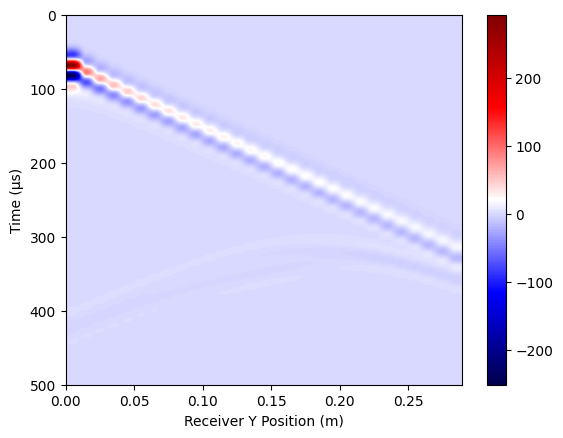

In [32]:
plt.imshow(p_rec[0][:,:29], aspect='auto', cmap='seismic',extent=[receiver_is[:29,1].min() * dx -0.15, receiver_is[:29,1].max() * dx -0.15, T*1e6,0])
plt.ylabel('Time (µs)')
plt.xlabel('Receiver Y Position (m)')
plt.colorbar()

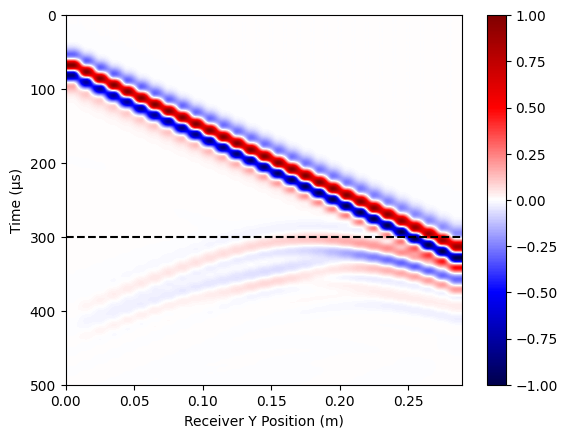

In [33]:
plt.imshow(p_rec_normalized[:,:29], aspect='auto', cmap='seismic' ,extent=[ receiver_is[:29,1].min() * dx -0.15, receiver_is[:29,1].max() * dx -0.15, T*1e6,0])
plt.axhline(y=300, color='k', linestyle='--')
plt.ylabel('Time (µs)')
plt.xlabel('Receiver Y Position (m)')
plt.colorbar()

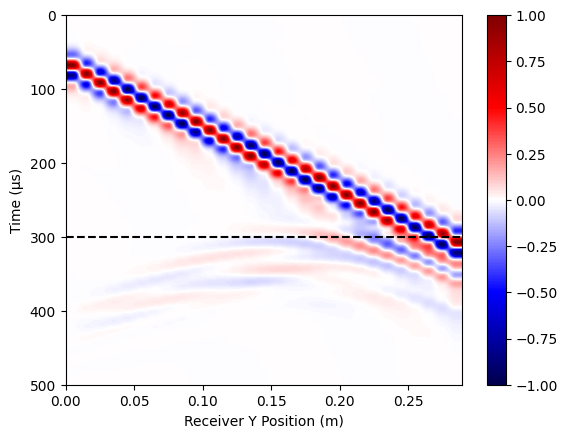

In [34]:
# plota shot gather
plt.imshow(out_normalized[0:29].T, aspect='auto', cmap='seismic',extent=[ receiver_is[0:29,1].min() * dx - 0.15, receiver_is[0:29,1].max() * dx - 0.15,T*1e6,0]   )
plt.axhline(y=300, color='k', linestyle='--', label="300 µs")
plt.ylabel('Time (µs)')
plt.xlabel('Receiver Y Position (m)')
plt.colorbar()

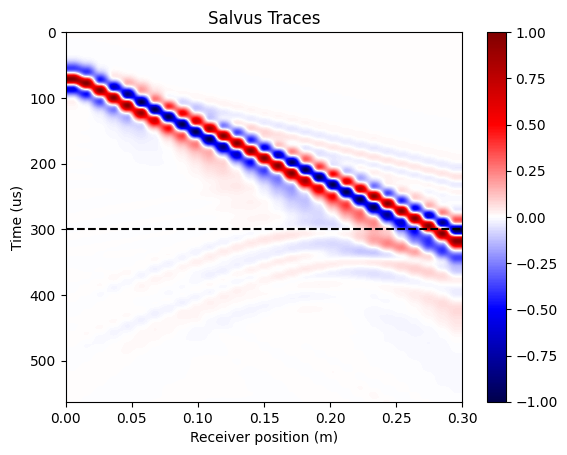

In [35]:
plt.imshow(salvus_traces_normalized[src_num,0:29,:].T, aspect='auto', cmap='seismic',extent=[0,30*0.01, salvus_time[-1]*1e6,salvus_time[0]*1e6])
plt.axhline(y=300, color='k', linestyle='--', label="300 µs")
plt.ylabel('Time (us)')
plt.xlabel('Receiver position (m)')
plt.title('Salvus Traces')
plt.colorbar()

In [36]:
p_rec[0][:,0:29].shape

(1695, 29)

In [37]:
print(jnp.mean((out[0:29].T - salvus_traces_interp[src_num,0:29,:].T) ** 2))
print(jnp.mean((p_rec[0][:,0:29] - salvus_traces_interp[src_num,0:29,:].T) ** 2))

117.21356
117.213135


In [38]:
print(jnp.mean((p_rec_normalized[:,0:29] - salvus_traces_normalized[src_num,0:29,:].T) ** 2))
print(jnp.mean((out_normalized[0:29].T - salvus_traces_normalized[src_num,0:29,:].T) ** 2))


0.05414302
0.060955156


  0%|          | 0/10 [00:00<?, ?it/s]

(900, 1695) (900, 1695)


 10%|█         | 1/10 [01:10<10:35, 70.64s/it]


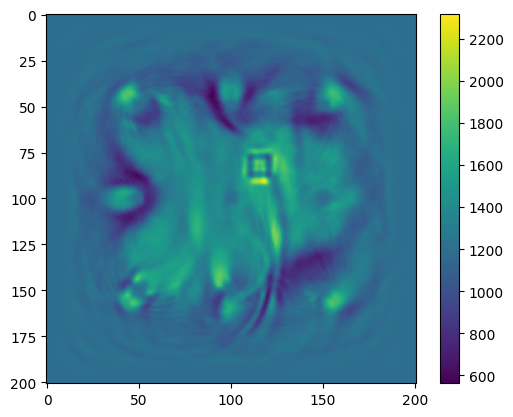

86304.445


In [39]:
from tqdm import tqdm

# Wrap the fwi function with a progress bar

# Create a wrapper to track progress during FWI iterations
def fwi_with_progress(src_indices, pbar=None):
    result = fwi(src_indices)
    if pbar is not None:
        pbar.update(1)
    return result

iin = fwi_with_progress(src_indices, pbar=tqdm(range(10)))
plt.imshow(iin)
plt.colorbar()
plt.show()
# L1 loss
print(jnp.linalg.norm((iin - jnp.fliplr(true_model)), ord=1))